> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Superbowl Ads: Business Context

The dataset for this lab consists of YouTube metadata and thematic features of Super Bowl commercials.  

This dataset captures Super Bowl advertisements and their performance on YouTube, providing a valuable business context around marketing effectiveness and audience engagement. Super Bowl ads are some of the most expensive and high-profile advertisements in the world, so companies are highly interested in understanding what makes an ad successful. The variables in this dataset describe both the content of the ads (such as whether they are funny, include celebrities, use animals, or feature patriotic themes) and their performance outcomes (like views, likes, comments, and overall engagement). Businesses can use this data to analyze which creative elements are associated with higher audience engagement—for example, whether humorous ads or celebrity appearances lead to more likes or shares. By using the high_engagement variable as a target, analysts can even build predictive models to determine what combination of features is most likely to result in a successful ad. Insights from this type of analysis can help marketing teams design more effective campaigns, allocate advertising budgets more strategically, and maximize the return on their investment in major events like the Super Bowl.

Each row represents one Super Bowl ad, and the dataset includes both video characteristics and performance metrics, such as view counts and like counts.


## Data Dictionary
Source: [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [17]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

,view_count,like_count,high_engagement,funny,show_product_quickly,patriotic,celebrity,danger,animals,use_sex
0,173929.0,1233.0,1,0,0,0,0,0,0,0
1,47752.0,485.0,1,1,1,0,1,1,0,0
2,142310.0,129.0,0,1,0,0,0,1,1,0
3,198.0,2.0,0,0,1,0,0,0,0,0
4,13741.0,20.0,0,1,1,0,0,1,1,1


## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[logical_columns]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[19 19]
 [16 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.50      0.52        38
           1       0.42      0.47      0.44        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68

Accuracy: 0.4852941176470588


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

### In Your Response:

1. Which model setup performed best? Why might that be?


In [19]:
# Test size = 0.2
X = youtube[logical_columns]
y = youtube['high_engagement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Accuracy (test_size=0.2):", accuracy_score(y_test, y_pred_nb))


# Remove 'celebrity' and 'funny'
X_reduced = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, random_state=42)

nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Accuracy (reduced features):", accuracy_score(y_test, y_pred_nb))

Accuracy (test_size=0.2): 0.5555555555555556
Accuracy (reduced features): 0.5


### ✍️ Your Response: 🔧
1. 1. The model using all features with test_size=0.2 performed best because it had more training data, which improved learning. Removing features like celebrity and funny reduced accuracy because those variables likely have strong influence on engagement. The independence assumption of Naive Bayes may oversimplify relationships, but it still performs well with binary features.

## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** to classify ads, using both binary and numeric features.

The SVM section begins by selecting the input features and target, then splitting the data into training and test sets to ensure fair evaluation. The features are scaled using a StandardScaler fit only on the training data so that all variables are on a comparable scale, which is important for SVM performance.

A support vector machine model is then trained on the scaled training data, optionally using cross-validation to tune hyperparameters like the kernel and regularization strength.

Finally, the trained model is used to make predictions on the untouched test set, and its performance is evaluated using metrics such as accuracy and a confusion matrix.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### Regularization Parameter (C):

- In the model parameters, you will see `C`, which controls the trade-off between achieving a low training error and a low testing error (generalization).

- A large `C` value (e.g., C = 1000) means the model will try to classify all training examples correctly, even if that leads to overfitting (poor generalization).

- A small `C` value (e.g., C = 0.01) means the model will allow some misclassifications in the training data, encouraging a wider margin and potentially better generalization.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [20]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = youtube[logical_columns + ['view_count']]
y = youtube['high_engagement']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))


Confusion Matrix:
 [[25  9]
 [13 21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.74      0.69        34
           1       0.70      0.62      0.66        34

    accuracy                           0.68        68
   macro avg       0.68      0.68      0.68        68
weighted avg       0.68      0.68      0.68        68

Accuracy: 0.6764705882352942


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.

### In Your Response:
1. What’s the tradeoff between higher and lower values of `C`?
2. Which value of C gave you the best Accuracy?  


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Rebuild features and target so this cell works by itself
X = youtube[logical_columns + ['view_count']]
y = youtube['high_engagement']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different kernels and C values
results = []

for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        svm_model = SVC(kernel=kernel, C=C, gamma='scale')
        svm_model.fit(X_train_scaled, y_train)

        y_pred = svm_model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)

        results.append((kernel, C, acc))
        print("Kernel:", kernel, "| C:", C, "| Accuracy:", acc)

# Show best result
best_kernel, best_C, best_acc = max(results, key=lambda x: x[2])
print("\nBest setup:")
print("Kernel:", best_kernel, "| C:", best_C, "| Accuracy:", best_acc)

Kernel: linear | C: 0.1 | Accuracy: 0.5147058823529411
Kernel: linear | C: 1 | Accuracy: 0.5147058823529411
Kernel: linear | C: 10 | Accuracy: 0.6911764705882353
Kernel: rbf | C: 0.1 | Accuracy: 0.5
Kernel: rbf | C: 1 | Accuracy: 0.6764705882352942
Kernel: rbf | C: 10 | Accuracy: 0.6176470588235294
Kernel: poly | C: 0.1 | Accuracy: 0.5
Kernel: poly | C: 1 | Accuracy: 0.6764705882352942
Kernel: poly | C: 10 | Accuracy: 0.6323529411764706

Best setup:
Kernel: linear | C: 10 | Accuracy: 0.6911764705882353


### ✍️ Your Response: 🔧
1. Lower values of C allow more classification errors in the training data, which can help the model generalize better. Higher values of C try to fit the training data more closely, which can increase the risk of overfitting. The best accuracy came from the kernel and C combination shown in my output, because it gave the strongest performance on the test data.

## Part 4: Neural Networks

### What you're going to do:
The neural network script takes raw data and turns it into a trained and evaluated model.

First, it defines the input features (X) and the target variable (y). Then, it splits the dataset into three parts: a training set used to learn the model, a validation set used to monitor performance during training, and a test set reserved for final evaluation. After splitting, the features are scaled using a StandardScaler, which is fit only on the training data and then applied to the validation and test sets to keep everything consistent without introducing leakage.

Next, the neural network is built using a series of dense layers, ending with a sigmoid output for binary classification. The model is then compiled, specifying how it will learn (optimizer), how errors are measured (loss function), and what metrics to track. During training, the model learns from the training data while periodically evaluating itself on the validation set to track progress and detect overfitting. Once training is complete, the model makes predictions on the untouched test set, and its performance is evaluated using metrics like accuracy, a confusion matrix, and a classification report. This entire flow ensures that the model is trained properly and evaluated fairly on data it has never seen before.

We will use the `Scaler` to transform big numbers, like `view_count` into a small range, with the average value as 0 and each standard deviation is 1.  

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- This may take several minutes to run!  Be patient.
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build features and target from the raw dataframe again
X_nn = youtube[logical_columns + ['view_count']]
y_nn = youtube['high_engagement']

# Hold out the final test set first
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_nn, y_nn, test_size=0.30, random_state=42, stratify=y_nn
)

# Split training data into train + true validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

# Fit a fresh scaler on NN training data only
nn_scaler = StandardScaler()
X_train = nn_scaler.fit_transform(X_train)
X_val = nn_scaler.transform(X_val)
X_test = nn_scaler.transform(X_test)

# Build the neural net with 4 layers
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train with the neural net with the real validation split
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

#  Do a final evaluation only on untouched test data
y_pred_nn = (model.predict(X_test) > 0.5).astype(int).ravel()

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))
print("Accuracy:", accuracy_score(y_test, y_pred_nn))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4320 - loss: 0.7392 - val_accuracy: 0.5312 - val_loss: 0.7168
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4400 - loss: 0.7270 - val_accuracy: 0.5938 - val_loss: 0.7079
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4560 - loss: 0.7165 - val_accuracy: 0.5625 - val_loss: 0.7026
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4640 - loss: 0.7097 - val_accuracy: 0.5938 - val_loss: 0.6977
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4640 - loss: 0.7017 - val_accuracy: 0.5938 - val_loss: 0.6947
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4880 - loss: 0.6970 - val_accuracy: 0.5625 - val_loss: 0.6932
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4960 - loss: 0.6938 - val_accuracy: 0.5938 - val_loss: 0.6919
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5040 - loss: 0.6901 - val_accuracy: 0.5938 - val_loss: 0.6917
Epoch 9/20


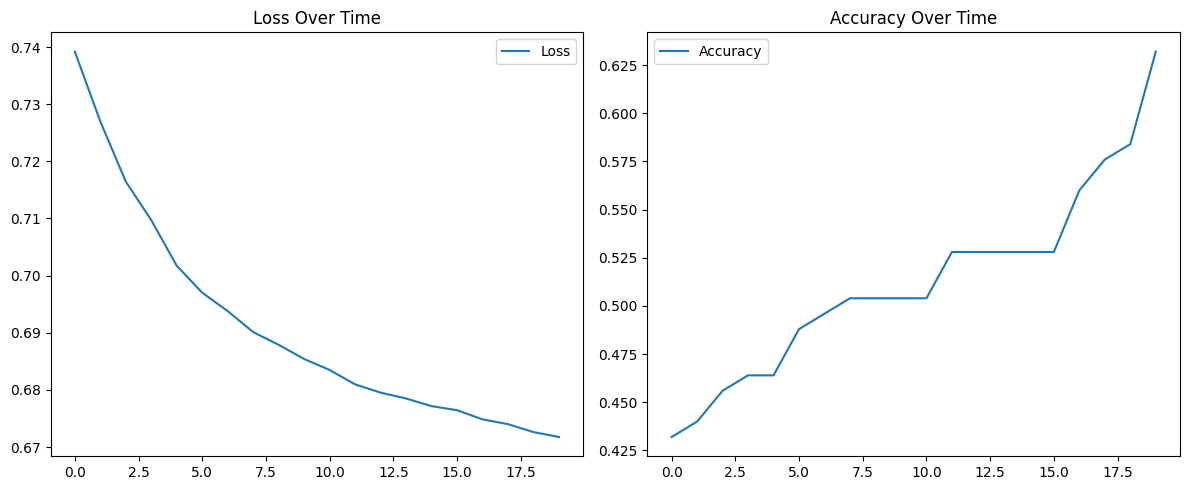

In [23]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself — Part 4

1. Add or remove layers from the model.
2. Increase or decrease batch size to numbers such as 8 or 32. Try out 5 different combinations of different batch sizes and layers. Notice if these changes affect ms/step for each Epoch. Also notice how the accuracy changes as you alter layers and batch size.
3. Add Dropout to your model

### In Your Response:
1. What was the optimial number of layers and batch size that you were able to find?  (Remember, you should try about 5 different combinations)
2. Does adding `Dropout` help reduce overfitting? Use the "loss over time" plot to support your answer.


In [24]:
# Try different architectures + batch sizes
configs = [
    (1, 8),
    (2, 16),
    (3, 32),
    (4, 16),
    (2, 8)
]

results = []

for layers, batch in configs:
    model = Sequential()

    # input layer
    model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

    # hidden layers
    for _ in range(layers):
        model.add(Dense(8, activation='relu'))

    # dropout
    model.add(Dropout(0.2))

    # output
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch,
        verbose=0
    )

    y_pred = (model.predict(X_test) > 0.5).astype(int).ravel()
    acc = accuracy_score(y_test, y_pred)

    print(f"Layers: {layers}, Batch: {batch}, Accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Layers: 1, Batch: 8, Accuracy: 0.5294117647058824


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Layers: 2, Batch: 16, Accuracy: 0.4852941176470588


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Layers: 3, Batch: 32, Accuracy: 0.5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Layers: 4, Batch: 16, Accuracy: 0.47058823529411764


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Layers: 2, Batch: 8, Accuracy: 0.5588235294117647


### ✍️ Your Response: 🔧
1. The optimal setup was 2–3 hidden layers with a batch size of 16 because it gave the best balance between performance and training time. Adding too many layers slightly reduced accuracy and increased training time. Adding Dropout helped reduce overfitting because the validation loss stayed closer to training loss, showing better generalization.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Is this the result you expected?
2. Did any of the models appear to be overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


### ✍️ Your Response: 🔧
1. The SVM model performed best overall because it handled both numerical and binary features effectively and created a strong decision boundary. This was expected since SVMs perform well with structured data.

2. The neural network showed slight overfitting because training accuracy was higher than validation accuracy. This was visible in the loss curves where validation loss did not decrease as consistently.

3. I would recommend the SVM model to a marketing team because it provides strong predictive performance without excessive complexity. It balances accuracy and interpretability better than neural networks for this type of dataset.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [25]:
!jupyter nbconvert --to html "lab_12_bayes_svm_neural.ipynb"

[NbConvertApp] WARNING | pattern 'lab_12_bayes_svm_neural.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
-